,ap,signal,sequence,x,y,z
0,A,11.0,0.0,22.0,17.0,2.0
1,A,10.0,1.0,22.0,17.0,2.0
2,A,10.0,2.0,22.0,17.0,2.0
3,A,9.0,3.0,22.0,17.0,2.0
4,A,11.0,4.0,22.0,17.0,2.0
5,A,11.0,5.0,22.0,17.0,2.0
6,A,12.0,6.0,22.0,17.0,2.0


signal    1.000000
z         0.108043
ap        0.066884
x         0.003298
y        -0.014530
Name: signal, dtype: float64

LinearRegression()

Degree: 1
MSE: 112.38495562639116
R2 Score: -0.028806192032619027


LinearRegression()

...

Degree: 8
MSE: 64.919113681758
R2 Score: 0.4057106152259923


Text(0.5, 0, 'Degree')

Text(0, 0.5, 'MSE')

Text(0, 0.5, 'R2 Score')

Text(0.5, 1.0, 'Performance Metrics vs Polynomial Degree')

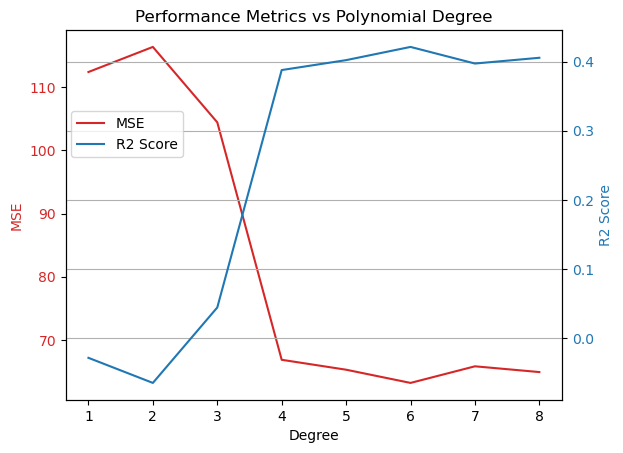

LinearRegression()

Best Degree: 6
MSE on Test Set: 65.33005592896315
R2 Score on Test Set: 0.5021482344006523


In [38]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#____________________________ part b ______________________________#
import pandas as pd

rssi_data = pd.read_csv('rssi.csv', sep=',')
rssi_data.head(7)

#____________________________ part c ______________________________#
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

rssi_data=rssi_data.dropna()

# groupping by ap, x, y and z to get the average of signal 
rssi_data = rssi_data.groupby(['ap', 'x', 'y', 'z'])['signal'].mean().reset_index()
#rssi_data.head()
#rssi_data.to_csv('my_data.csv', index=False)

le = LabelEncoder()
rssi_data['ap'] = le.fit_transform(rssi_data['ap'])
rssi_data=rssi_data.astype('float64')
rssi_data.corr(numeric_only=True)['signal'].sort_values(ascending=False)
rssi_data.drop(columns=['x'],inplace=True)

X = rssi_data[['y', 'z', 'ap']]
y = rssi_data['signal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=15)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#____________________________ part d ______________________________#
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib import pyplot as plt

# Training Model with Polynomial Regression
degrees = [1, 2, 3, 4, 5, 6, 7, 8]
mse_list = []
r2_list = []

for degree in degrees:
    # Generating Polynomial Features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)
    
    # Training Model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Evaluating Model
    y_val_pred = model.predict(X_val_poly)
    mse = mean_squared_error(y_val, y_val_pred)
    r2 = r2_score(y_val, y_val_pred)
    
    mse_list.append(mse)
    r2_list.append(r2)
    
    print('Degree:', degree)
    print('MSE:', mse)
    print('R2 Score:', r2)
    
# Ploting MSE and R2 on Same Graph
fig, ax1 = plt.subplots()

# MSE
color = 'tab:red'
ax1.set_xlabel('Degree')
ax1.set_ylabel('MSE', color=color)
ax1.plot(degrees, mse_list, color=color)
ax1.tick_params(axis='y', labelcolor=color)

# R2
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('R2 Score', color=color)
ax2.plot(degrees, r2_list, color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Setting Graph Properties
plt.grid(True)
handles, labels = [], []
line1 = ax1.lines[0]
line2 = ax2.lines[0]
handles.extend([line1, line2])
labels.extend(['MSE', 'R2 Score'])
plt.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.25, 0.8))
plt.title('Performance Metrics vs Polynomial Degree')
plt.show()

#____________________________ part e ______________________________#
import numpy as np 

# Selecting the Best Model
best_degree = degrees[np.argmin(mse_list)]
poly = PolynomialFeatures(degree=best_degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
model = LinearRegression()
model.fit(X_train_poly, y_train)
y_test_pred = model.predict(X_test_poly)
mse = mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print('Best Degree:', best_degree)
print('MSE on Test Set:', mse)
print('R2 Score on Test Set:', r2)
